# 01 - Exploracion Inicial De Datos

Proposito: entender la estructura, calidad y patrones iniciales del dataset antes de definir transformaciones o modelos.

## 1. Configuracion

Importar librerias, definir rutas y cargar utilidades del proyecto.

In [1]:
#!pip install seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Carga De Datos


In [3]:
#Solo usare datos de precipitacion del sil ya que son los unicos de los cuales tambien tengo la precipitacion en las mismas fechas
df_lluvia = pd.read_csv(r'G:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\data\raw\Datos_Stalder_27_abril\Lluvia.csv', parse_dates=["Time"])
df_lluvia.head()

,Time,Precipitacion Villa Morra
0,2025-08-27 15:00:00,0.0
1,2025-08-27 15:05:00,0.0
2,2025-08-27 15:10:00,0.0
3,2025-08-27 15:15:00,0.0
4,2025-08-27 15:20:00,0.0


In [4]:
df_lluvia.info()

<class 'pandas.DataFrame'>
RangeIndex: 58111 entries, 0 to 58110
Data columns (total 2 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Time                       58111 non-null  datetime64[us]
 1   Precipitacion Villa Morra  58111 non-null  float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 908.1 KB


In [4]:
#Datos de nivel del arroyo mburicao, el cual es el que quiero predecir
df_nivel = pd.read_csv(r'G:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\data\raw\Datos_Stalder_27_abril\Nivel.csv', parse_dates=["Time"])
df_nivel.head()

,Time,Nivel Colegio SIL
0,2025-08-27 15:10:00,0.45
1,2025-08-27 15:15:00,0.45
2,2025-08-27 15:20:00,0.45
3,2025-08-27 15:25:00,0.45
4,2025-08-27 15:30:00,0.45


In [5]:
df_nivel.info()

<class 'pandas.DataFrame'>
RangeIndex: 64127 entries, 0 to 64126
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Time               64127 non-null  datetime64[us]
 1   Nivel Colegio SIL  64127 non-null  float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 1002.1 KB


In [6]:
# Se aplica el método sort_index() de pandas ordena un DataFrame o Series según su índice (las filas, o también las columnas si se indica).
df_lluvia = df_lluvia.set_index("Time").sort_index()
df_nivel = df_nivel.set_index("Time").sort_index()

In [7]:
df_nivel.index

DatetimeIndex(['2025-08-27 15:10:00', '2025-08-27 15:15:00',
               '2025-08-27 15:20:00', '2025-08-27 15:25:00',
               '2025-08-27 15:30:00', '2025-08-27 15:35:00',
               '2025-08-27 15:40:00', '2025-08-27 15:45:00',
               '2025-08-27 15:50:00', '2025-08-27 15:55:00',
               ...
               '2026-04-27 09:00:00', '2026-04-27 09:05:00',
               '2026-04-27 09:05:00', '2026-04-27 09:10:00',
               '2026-04-27 09:15:00', '2026-04-27 09:20:00',
               '2026-04-27 09:25:00', '2026-04-27 09:30:00',
               '2026-04-27 09:35:00', '2026-04-27 09:40:00'],
              dtype='datetime64[us]', name='Time', length=64127, freq=None)

En este caso, ambos dataset ya han pasado por ese procesamiento, ambos ya estan sampleados a 10min y los indices ya fueron normalizados a intervalos de 10 min en multiplos de 10. Las muestraas ya estan sincronizadas

Ahora combinamos ambas series de datos en un solo dataset, para esto utilizamos el join, con el parametro "inner"
El parámetro how="inner" indica que se mantendrán solo los timestamps que existan en ambos datasets.
- Esto elimina registros donde falte información en una de las series (por ejemplo, una hora en que hay nivel pero no lluvia, o viceversa).

In [7]:
df_nuevos = df_nivel.join(df_lluvia, how="inner")

In [8]:
df_nuevos.info

<bound method DataFrame.info of                      Nivel Colegio SIL  Precipitacion Villa Morra
Time                                                             
2025-08-27 15:10:00               0.45                        0.0
2025-08-27 15:15:00               0.45                        0.0
2025-08-27 15:20:00               0.45                        0.0
2025-08-27 15:25:00               0.45                        0.0
2025-08-27 15:30:00               0.45                        0.0
...                                ...                        ...
2026-03-17 09:00:00               0.59                        0.0
2026-03-17 09:05:00               0.59                        0.0
2026-03-17 09:20:00               0.59                        0.0
2026-03-17 09:25:00               0.59                        0.0
2026-03-17 09:30:00               0.59                        0.0

[50946 rows x 2 columns]>

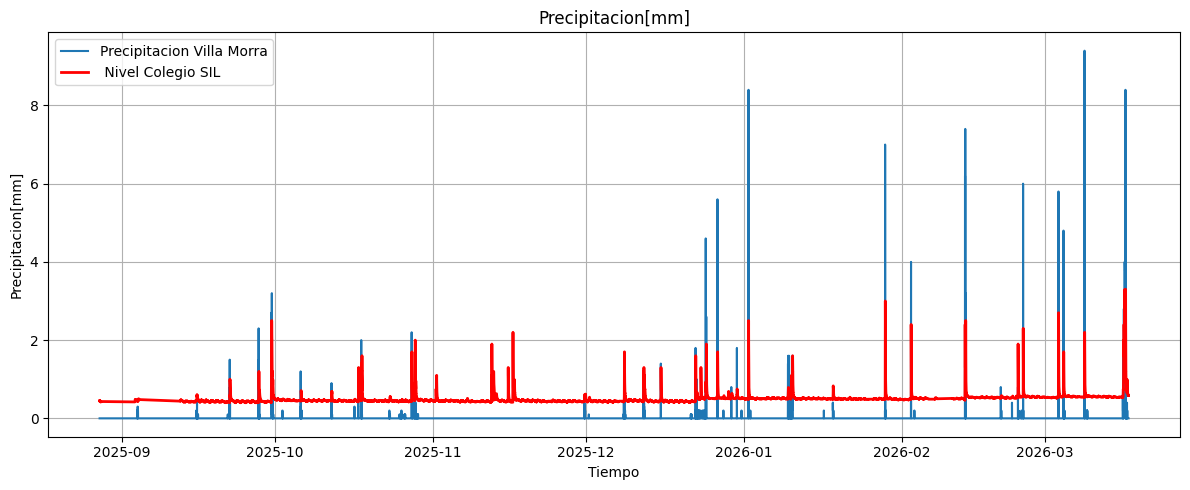

In [9]:
#grafiquemos las series de precipitaciones y nivel para ver que ocurre

# --- Gráfico comparativo ---
plt.figure(figsize=(12, 5))
plt.plot(df_nuevos.index, df_nuevos["Precipitacion Villa Morra"], label="Precipitacion Villa Morra", alpha=1)
plt.plot(df_nuevos.index, df_nuevos["Nivel Colegio SIL"], label=" Nivel Colegio SIL", alpha=1, color="red", linewidth=2)
plt.title("Precipitacion[mm]")
plt.xlabel("Tiempo")
plt.ylabel("Precipitacion[mm]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Estos son los datos nuevos, ahora necesito hacer el merge de estos con los datos iniciales

In [10]:
# Se cargan los datos del SIL
df_originales = pd.read_csv(r'G:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\data\processed\datos_lluvia_nivel\mburicao_sil_merged_2021-2022.csv', parse_dates=["Fecha"])
df_originales= df_originales.set_index("Fecha").sort_index()
df_originales.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 34858 entries, 2021-06-12 12:00:00 to 2022-04-01 16:30:00
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   nivel              34858 non-null  float64
 1   Precipitacion[mm]  34858 non-null  float64
dtypes: float64(2)
memory usage: 817.0 KB


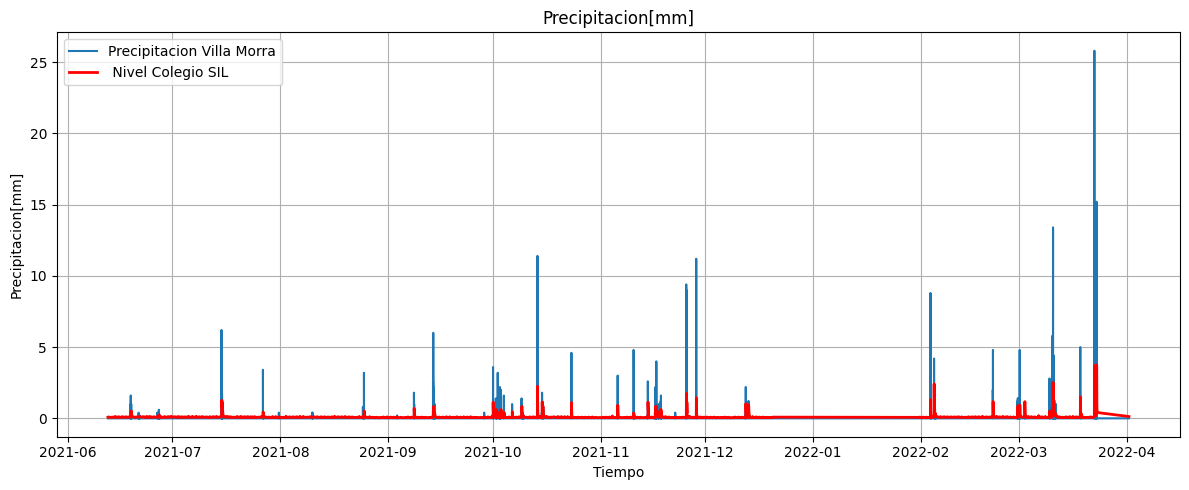

In [11]:
#grafiquemos las series de precipitaciones y nivel para ver que ocurre

# --- Gráfico comparativo ---
plt.figure(figsize=(12, 5))
plt.plot(df_originales.index, df_originales["Precipitacion[mm]"], label="Precipitacion Villa Morra", alpha=1)
plt.plot(df_originales.index, df_originales["nivel"], label=" Nivel Colegio SIL", alpha=1, color="red", linewidth=2)
plt.title("Precipitacion[mm]")
plt.xlabel("Tiempo")
plt.ylabel("Precipitacion[mm]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

A simple vista lo primero que noto es la diferencia entre los valores medios del nivel, veamos cuanto es exactamente:

In [12]:
print("2021",df_originales["nivel"].mean())
print("2025",df_nuevos["Nivel Colegio SIL"].mean())

2021 0.09366980976922497
2025 0.4982930946492365


## Que cambiaria si le saco el valor medio al dataset de datos del 2025-2026 ? 

al fin y al cabo lo que me interesa a mi es la crecida, no el valor medio, que implicancias tendria desde el punto de vista hidrologico ? 

La conclusion es que ahora mismo no, me interesa la variacion, todavia no el valor final ya que hasta ahora el nivel del arroyo aun no llego a subir lo suficiente como para que rebose el cause

In [15]:
media = df_nuevos["Nivel Colegio SIL"].mean()
df_nuevos["Nivel Colegio SIL"] = df_nuevos["Nivel Colegio SIL"] - media
print("2025 ajustado",df_nuevos["Nivel Colegio SIL"].mean())

2025 ajustado -2.2315164629532454e-18


## Hay que realizar una concatenacion de ambos sets de datos


In [13]:
df_originales.rename(columns={"Precipitacion[mm]": "Precipitacion"},inplace=True)
df_nuevos.rename(columns={"Precipitacion Villa Morra": "Precipitacion"},inplace=True)

df_originales.rename(columns={"nivel": "Nivel"},inplace=True)
df_nuevos.rename(columns={"Nivel Colegio SIL": "Nivel"},inplace=True)

In [14]:
df_nuevos.columns

Index(['Nivel', 'Precipitacion'], dtype='str')

In [15]:
df_originales.columns

Index(['Nivel', 'Precipitacion'], dtype='str')

In [16]:
#df_total = pd.concat([df_originales, df_nuevos], axis=0)
df_total = df_nuevos.copy()


In [17]:
df_total.head()


,Nivel,Precipitacion
Time,,
2025-08-27 15:10:00,0.45,0.0
2025-08-27 15:15:00,0.45,0.0
2025-08-27 15:20:00,0.45,0.0
2025-08-27 15:25:00,0.45,0.0
2025-08-27 15:30:00,0.45,0.0


In [18]:
df_total.tail()

,Nivel,Precipitacion
Time,,
2026-03-17 09:00:00,0.59,0.0
2026-03-17 09:05:00,0.59,0.0
2026-03-17 09:20:00,0.59,0.0
2026-03-17 09:25:00,0.59,0.0
2026-03-17 09:30:00,0.59,0.0


In [19]:
df_total.shape

(50946, 2)

In [20]:
df_total.index.min(), df_total.index.max()

(Timestamp('2025-08-27 15:10:00'), Timestamp('2026-03-17 09:30:00'))

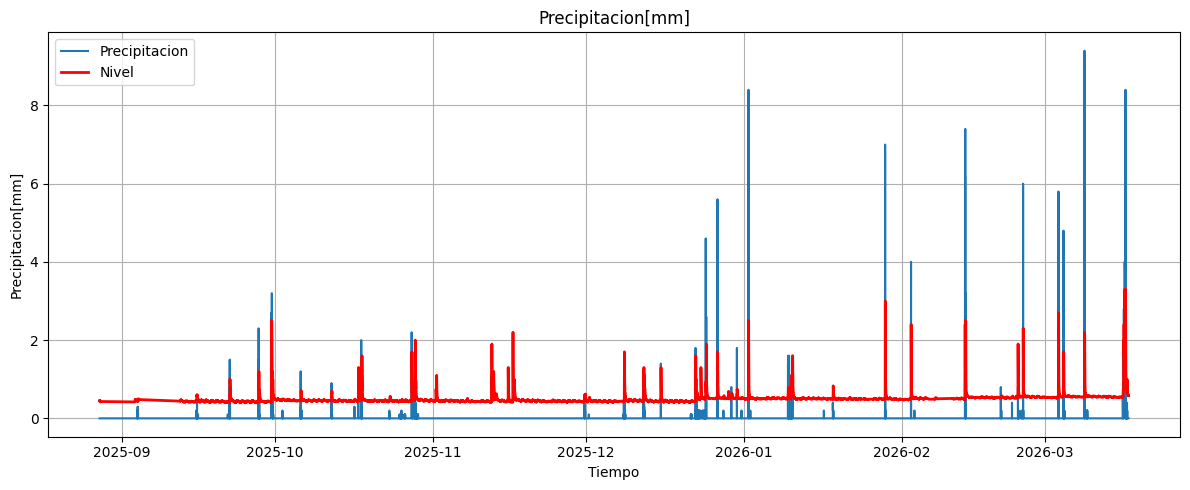

In [21]:
#grafiquemos las series de precipitaciones y nivel para ver que ocurre

# --- Gráfico comparativo ---
plt.figure(figsize=(12, 5))
plt.plot(df_total.index, df_total["Precipitacion"], label="Precipitacion", alpha=1)
plt.plot(df_total.index, df_total["Nivel"], label="Nivel", alpha=1, color="red", linewidth=2)
plt.title("Precipitacion[mm]")
plt.xlabel("Tiempo")
plt.ylabel("Precipitacion[mm]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
df_total.to_csv(r"G:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\data\processed\datos_lluvia_nivel\Mburicao_2025.csv", index_label="Time")